In [1]:
import sys
import os

# Get the absolute path of the project root
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
import logging
import os
import warnings

# --- Disable Streamlit internal logs before it initializes ---
os.environ["STREAMLIT_SUPPRESS_LOGS"] = "1"
logging.getLogger(
    "streamlit.runtime.caching.cache_data_api").setLevel(logging.ERROR)
logging.getLogger("streamlit").setLevel(logging.ERROR)

# --- Suppress Python warnings ---
warnings.filterwarnings("ignore", category=FutureWarning, module="yfinance")
warnings.filterwarnings("ignore", category=UserWarning, module="streamlit")

In [3]:

import numpy as np
import pandas as pd
import streamlit as st
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from data.data_loader import load_data

2025-11-11 09:51:07.877 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


In [4]:
df = load_data('UNI-USD')
df.head()

2025-11-11 09:51:07.897 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
c:\Users\parth\OneDrive - Southampton Solent University\COM724 - Assessment(AI)\data\data_loader.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, START_DATE, TODAY)
[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2019-10-21,0.007594,0.007935,0.006916,0.007928,330158
1,2019-10-22,0.015731,0.015731,0.007488,0.007593,5577523
2,2019-10-23,0.017918,0.017925,0.009440,0.015731,992886
3,2019-10-24,0.019045,0.019139,0.013160,0.017897,914610
4,2019-10-25,0.013240,0.019045,0.011634,0.019045,405408


## Understand The Dataset

In [5]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2019-10-21,0.007594,0.007935,0.006916,0.007928,330158
1,2019-10-22,0.015731,0.015731,0.007488,0.007593,5577523
2,2019-10-23,0.017918,0.017925,0.009440,0.015731,992886
3,2019-10-24,0.019045,0.019139,0.013160,0.017897,914610
4,2019-10-25,0.013240,0.019045,0.011634,0.019045,405408


In [6]:
df.tail()

,Date,Close,High,Low,Open,Volume
2001,2025-04-13,0.000163,0.000163,0.000163,0.000163,0
2002,2025-04-14,0.000163,0.000163,0.000163,0.000163,0
2003,2025-04-15,0.000163,0.000163,0.000163,0.000163,0
2004,2025-04-16,0.000163,0.000163,0.000163,0.000163,0
2005,2025-04-17,0.000163,0.000163,0.000163,0.000163,0


In [7]:
df.shape

(2006, 6)

In [8]:
# Set Date as index for time series analysis

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2006 entries, 2019-10-21 to 2025-04-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2006 non-null   float64
 1   High    2006 non-null   float64
 2   Low     2006 non-null   float64
 3   Open    2006 non-null   float64
 4   Volume  2006 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 94.0 KB


In [10]:
df.describe()

,Close,High,Low,Open,Volume
count,2006.000000,2006.000000,2006.000000,2006.000000,2.006000e+03
mean,0.001280,0.001902,0.000864,0.001284,1.551042e+05
std,0.018345,0.030038,0.011027,0.018346,8.185759e+05
min,0.000037,0.000038,0.000037,0.000037,0.000000e+00
25%,0.000128,0.000131,0.000124,0.000128,5.000000e+00
50%,0.000200,0.000209,0.000193,0.000200,1.600000e+01
75%,0.000343,0.000414,0.000285,0.000344,6.000000e+01
max,0.598153,1.041814,0.358100,0.598153,8.397127e+06


## Data Cleaning

In [11]:
df.isna().sum() # Check for missing values

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [55]:
df.ffill(inplace=True)  # Filling the missing values with Forward fill method

In [13]:
df.duplicated().sum()  # Check for duplicate rows

70

In [14]:
df.drop_duplicates(inplace=True)  # Remove duplicate rows if any

## Univariate Analysis

In [15]:
df.describe()

,Close,High,Low,Open,Volume
count,1936.000000,1936.000000,1936.000000,1936.000000,1.936000e+03
mean,0.001320,0.001965,0.000889,0.001324,1.607121e+05
std,0.018673,0.030575,0.011224,0.018674,8.327094e+05
min,0.000037,0.000038,0.000037,0.000037,0.000000e+00
25%,0.000130,0.000134,0.000126,0.000130,5.000000e+00
50%,0.000201,0.000210,0.000194,0.000201,1.700000e+01
75%,0.000349,0.000436,0.000291,0.000350,6.525000e+01
max,0.598153,1.041814,0.358100,0.598153,8.397127e+06


### Checking the normality

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

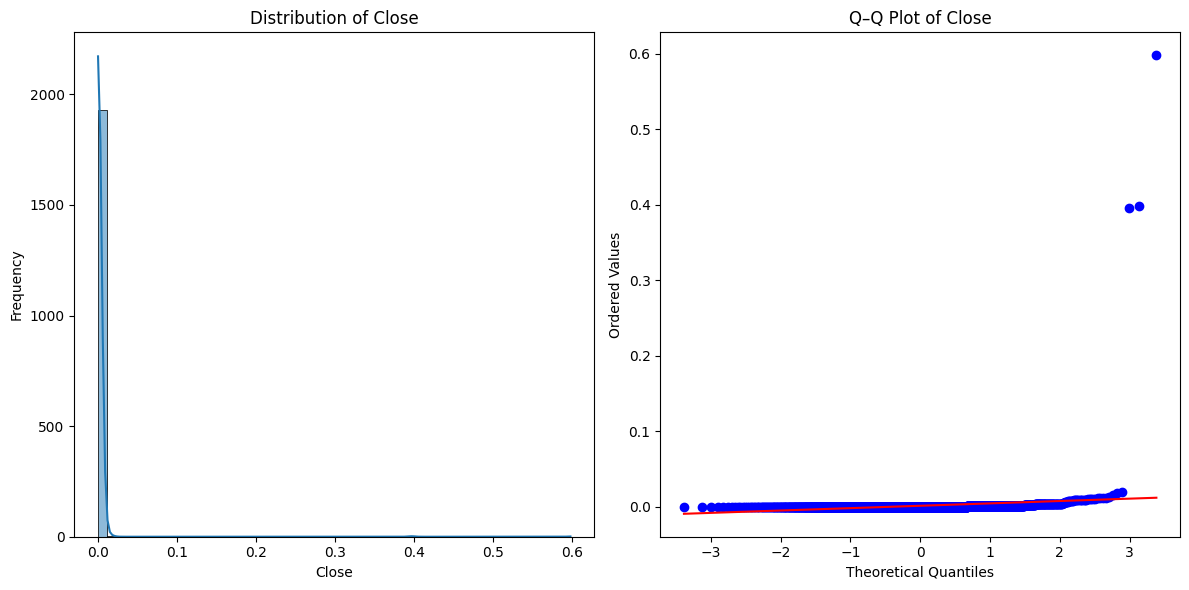

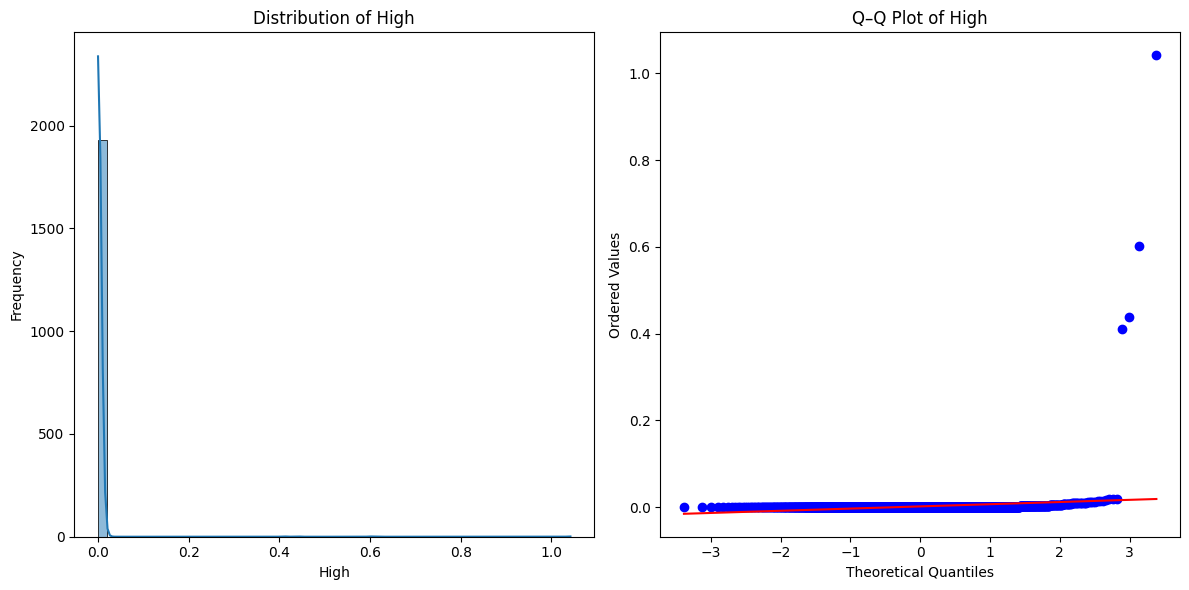

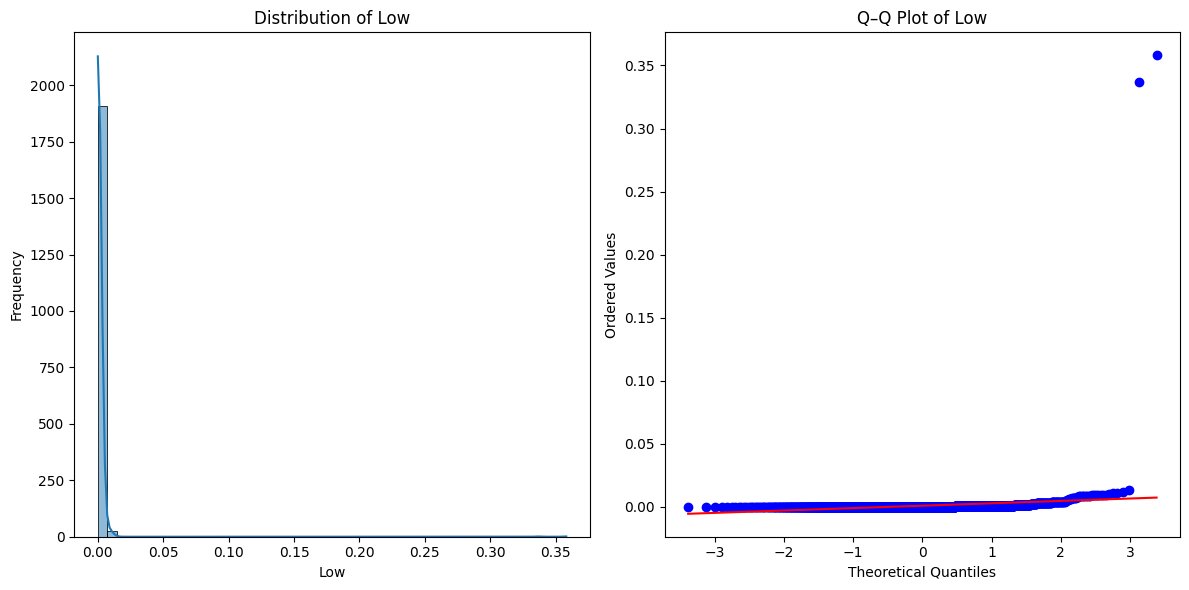

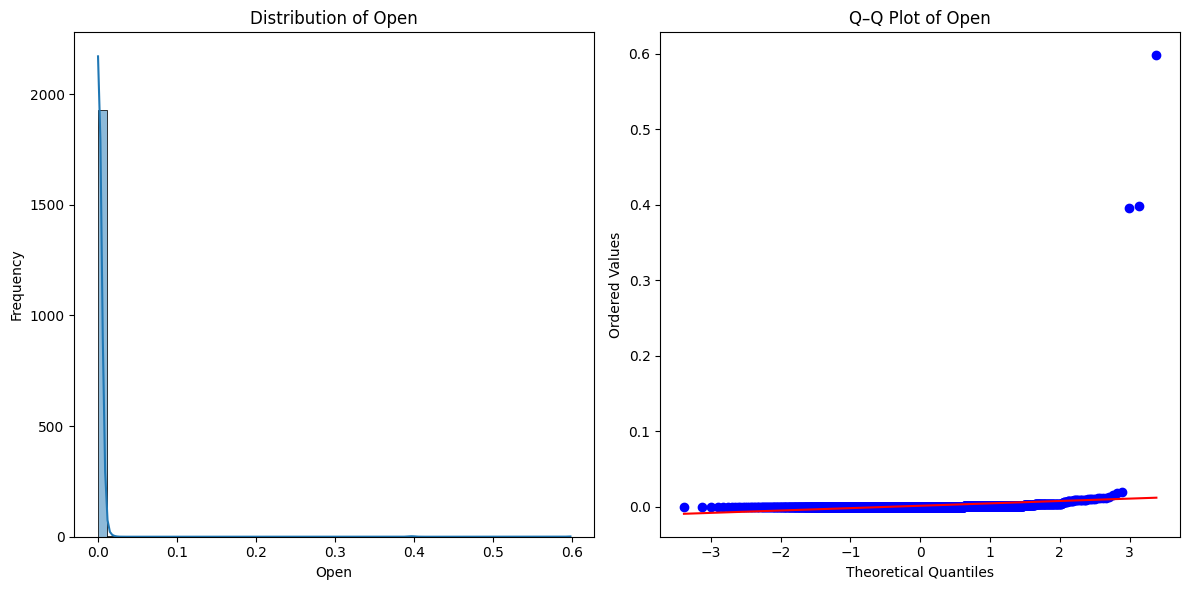

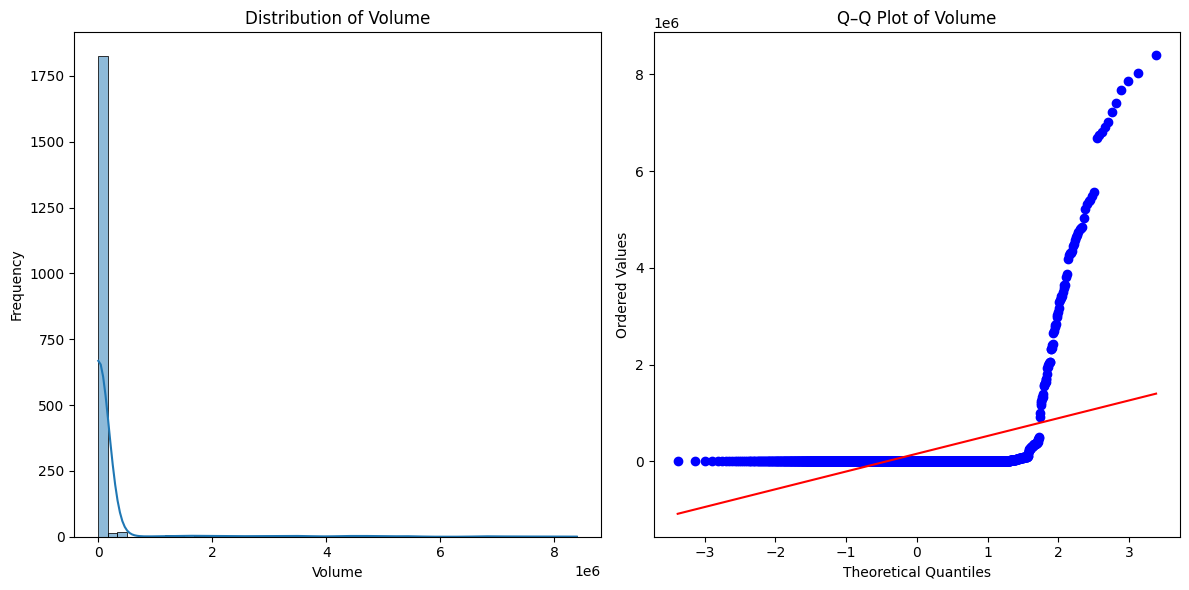

In [17]:
# Applying QQPlot and Histogram to check normality

%matplotlib inline

# Loop through all numeric columns in the DataFrame
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    # Create subplots: one row, two columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # --- Left: Histogram with KDE ---
    sns.histplot(df[col], kde=True, bins=50, ax=ax1)
    ax1.set_title(f'Distribution of {col}')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Frequency')

    # --- Right: Q–Q Plot ---
    stats.probplot(df[col].dropna(), dist="norm", plot=ax2)
    ax2.set_title(f"Q–Q Plot of {col}")
    ax2.set_xlabel('Theoretical Quantiles')
    ax2.set_ylabel('Ordered Values')

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

In [18]:
from sklearn.preprocessing import (
    FunctionTransformer, PowerTransformer,
    StandardScaler, MinMaxScaler, RobustScaler
)

In [19]:
df_new = df.copy()  # Create a copy of the original DataFrame

In [20]:
transformations = {
    'Log': FunctionTransformer(np.log1p),
    'Sqrt': FunctionTransformer(np.sqrt),
    'Cbrt': FunctionTransformer(np.cbrt),
    'Reciprocal': FunctionTransformer(lambda x: 1 / (x + 1e-9)),
    # Yeo-Johnson works with zero/negative values
    'YeoJohnson': PowerTransformer(method='yeo-johnson'),
    # Box-Cox requires all positive data
    'BoxCox': PowerTransformer(method='box-cox'),
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler()
}

# Apply transformations to every numeric column
for col in df_new.select_dtypes(include=['float64', 'int64']).columns:
    for name, transformer in transformations.items():
        try:
            # Box-Cox requires strictly positive values
            if name == 'BoxCox' and (df_new[col] <= 0).any():
                continue  # Skip if column has zero or negative values

            df_new[f'{col}_{name}'] = transformer.fit_transform(df_new[[col]])

        except Exception as e:
            print(f"⚠️ Skipping {col}_{name} due to error: {e}")

In [21]:
df_new.head()

,Close,High,Low,Open,Volume,Close_Log,Close_Sqrt,Close_Cbrt,Close_Reciprocal,Close_YeoJohnson,...,Open_MinMax,Open_Robust,Volume_Log,Volume_Sqrt,Volume_Cbrt,Volume_Reciprocal,Volume_YeoJohnson,Volume_Standard,Volume_MinMax,Volume_Robust
Date,,,,,,,,,,,,,,,,,,,,,
2019-10-21,0.007594,0.007935,0.006916,0.007928,330158,0.007565,0.087144,0.196558,131.682889,3.519692,...,0.013193,35.082861,12.707330,574.593770,69.115259,3.028853e-06,1.860212,0.203540,0.039318,5479.518672
2019-10-22,0.015731,0.015731,0.007488,0.007593,5577523,0.015609,0.125423,0.250564,63.568748,3.554527,...,0.012633,33.561862,15.534256,2361.678005,177.342893,1.792911e-07,1.958193,6.506724,0.664218,92572.713693
2019-10-23,0.017918,0.017925,0.009440,0.015731,992886,0.017759,0.133858,0.261676,55.809797,3.554677,...,0.026239,70.510784,13.808372,996.436651,99.762302,1.007165e-06,1.906602,0.999615,0.118241,16479.153527
2019-10-24,0.019045,0.019139,0.013160,0.017897,914610,0.018866,0.138004,0.267051,52.507215,3.554703,...,0.029860,80.345069,13.726254,956.352445,97.068574,1.093362e-06,1.903559,0.905589,0.108919,15179.966805
2019-10-25,0.013240,0.019045,0.011634,0.019045,405408,0.013153,0.115065,0.236572,75.528694,3.553756,...,0.031780,85.557330,12.912652,636.716577,74.011199,2.466651e-06,1.869842,0.293931,0.048279,6728.481328


In [22]:
df_new.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Close_Log', 'Close_Sqrt',
       'Close_Cbrt', 'Close_Reciprocal', 'Close_YeoJohnson', 'Close_BoxCox',
       'Close_Standard', 'Close_MinMax', 'Close_Robust', 'High_Log',
       'High_Sqrt', 'High_Cbrt', 'High_Reciprocal', 'High_YeoJohnson',
       'High_BoxCox', 'High_Standard', 'High_MinMax', 'High_Robust', 'Low_Log',
       'Low_Sqrt', 'Low_Cbrt', 'Low_Reciprocal', 'Low_YeoJohnson',
       'Low_BoxCox', 'Low_Standard', 'Low_MinMax', 'Low_Robust', 'Open_Log',
       'Open_Sqrt', 'Open_Cbrt', 'Open_Reciprocal', 'Open_YeoJohnson',
       'Open_BoxCox', 'Open_Standard', 'Open_MinMax', 'Open_Robust',
       'Volume_Log', 'Volume_Sqrt', 'Volume_Cbrt', 'Volume_Reciprocal',
       'Volume_YeoJohnson', 'Volume_Standard', 'Volume_MinMax',
       'Volume_Robust'],
      dtype='object')

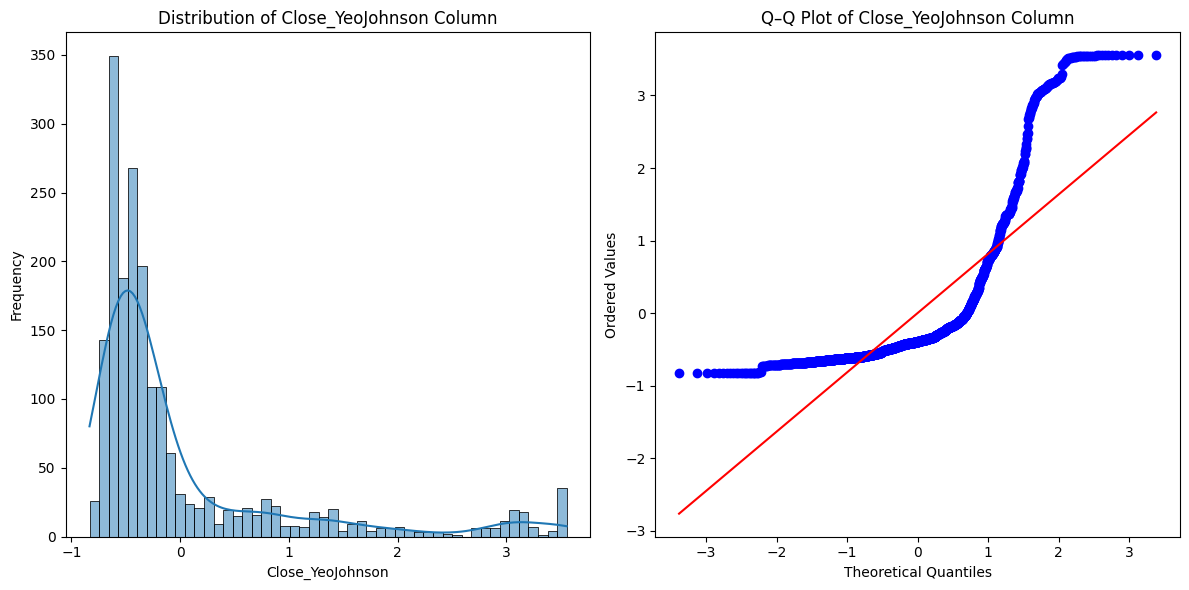

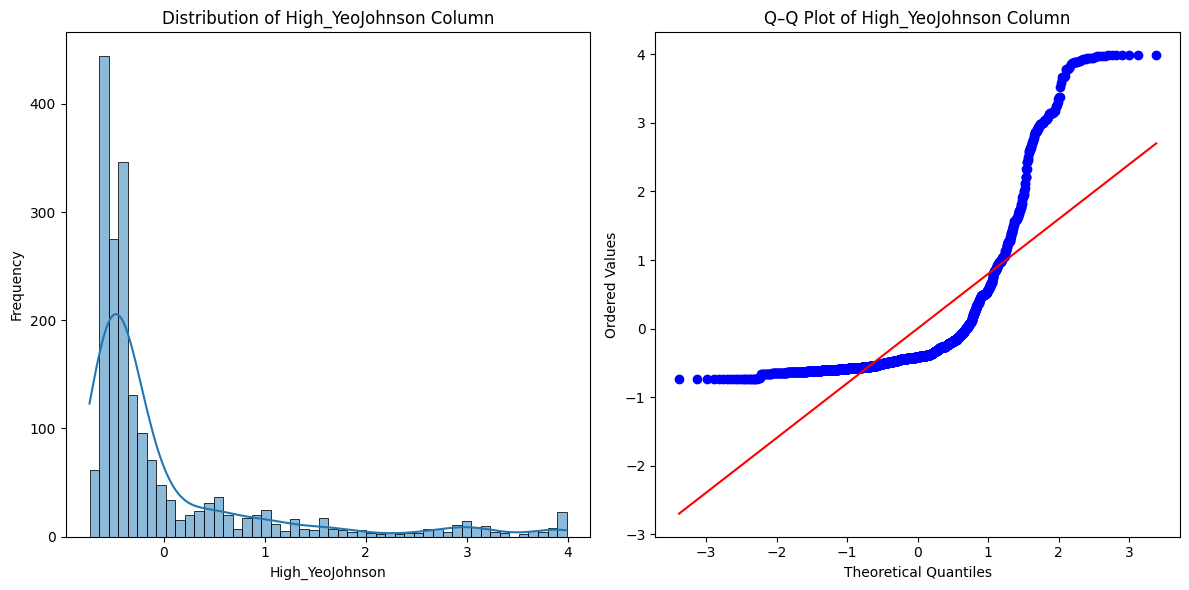

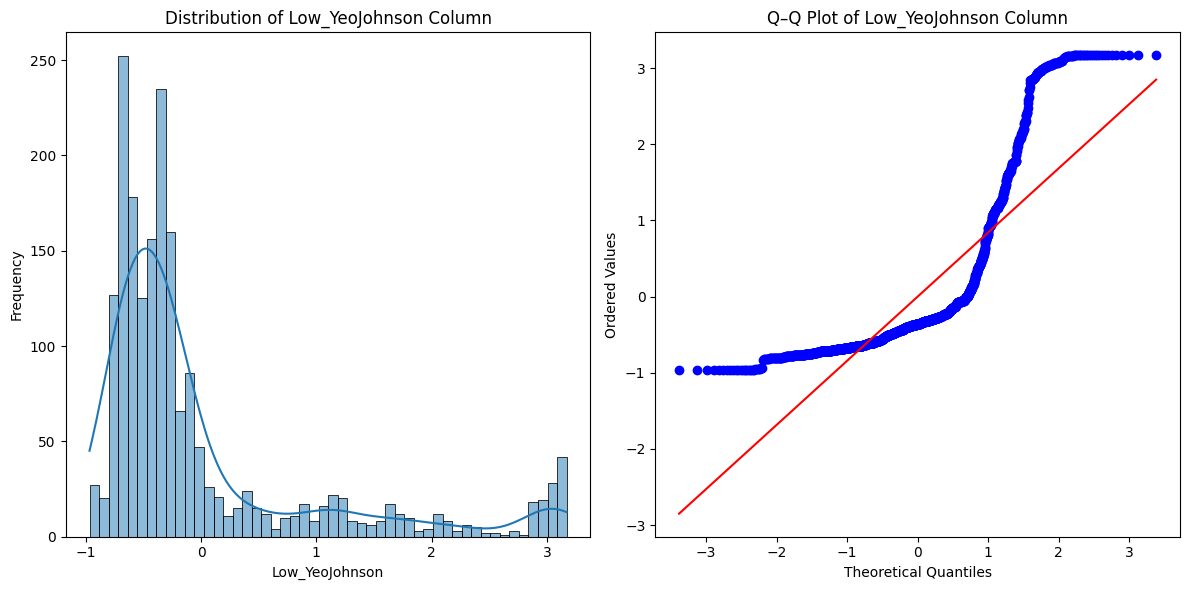

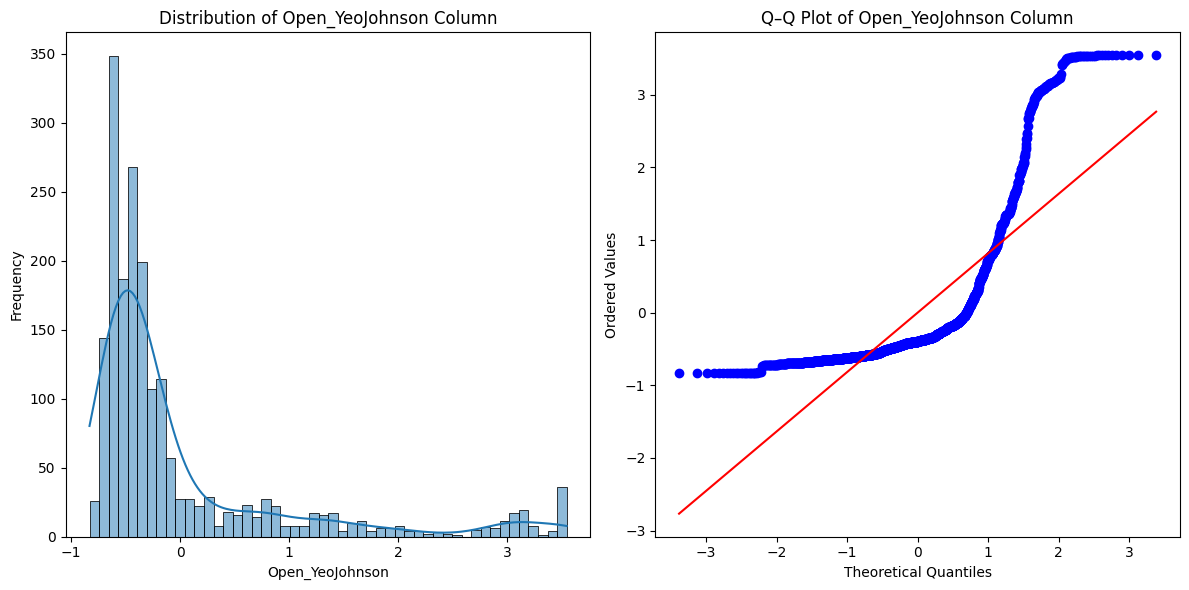

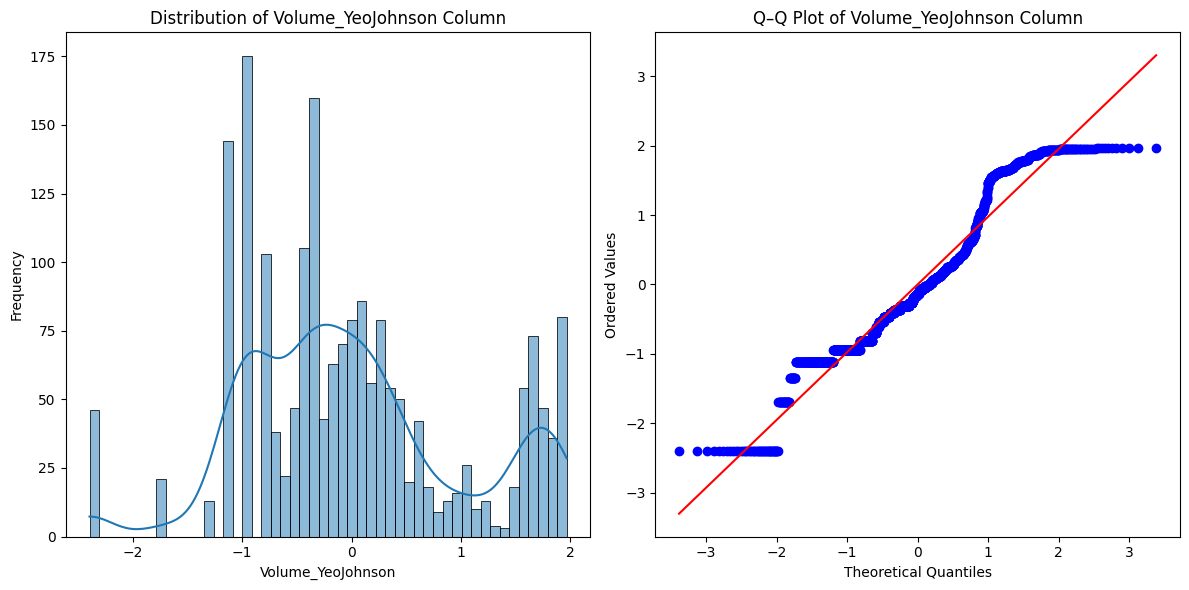

In [23]:
# Loop over all columns that end with '_YeoJohnson'
for col in [c for c in df_new.columns if c.endswith('_YeoJohnson')]:
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # --- Left: Histogram with KDE ---
    sns.histplot(df_new[col].dropna(), kde=True, bins=50, ax=ax1)
    ax1.set_title(f'Distribution of {col} Column')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Frequency')

    # --- Right: Q–Q Plot ---
    stats.probplot(df_new[col].dropna(), dist="norm", plot=ax2)
    ax2.set_title(f"Q–Q Plot of {col} Column")
    ax2.set_xlabel('Theoretical Quantiles')
    ax2.set_ylabel('Ordered Values')

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

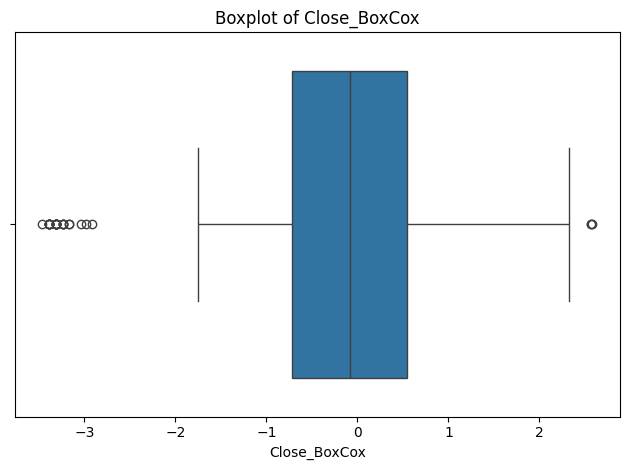

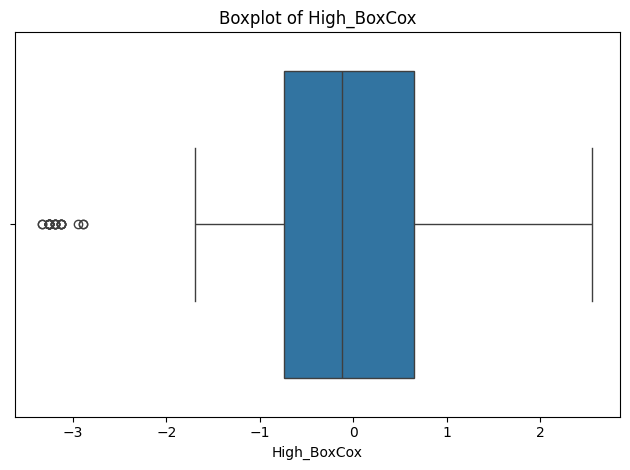

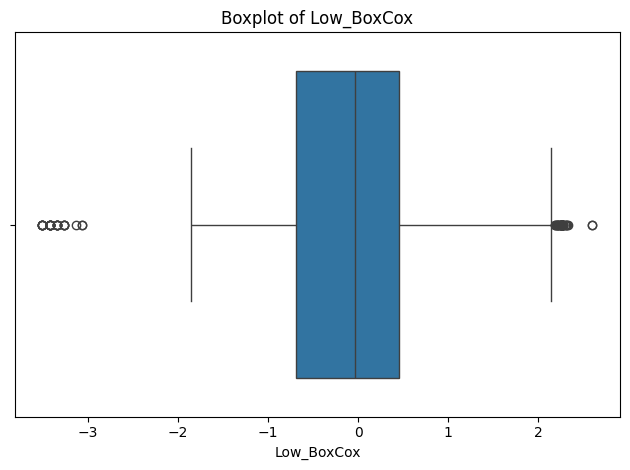

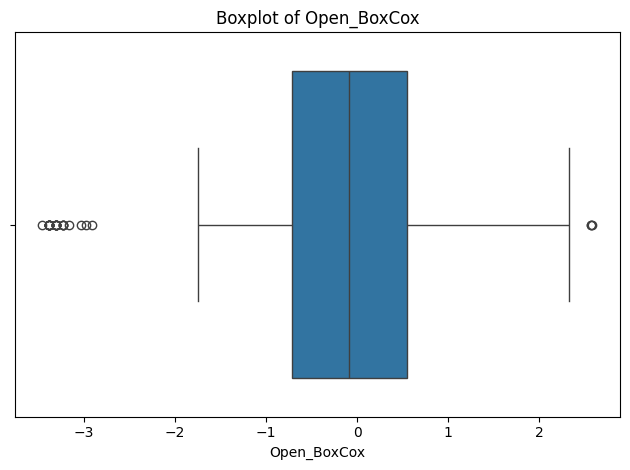

In [25]:
# Loop through all columns ending with '_BoxCox'
for col in [c for c in df_new.columns if c.endswith('_BoxCox')]:
    plt.figure()
    sns.boxplot(x=df_new[col], orient='h')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Removing The Outliers

#### Trimming

In [27]:
df_new.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Close_Log', 'Close_Sqrt',
       'Close_Cbrt', 'Close_Reciprocal', 'Close_YeoJohnson', 'Close_BoxCox',
       'Close_Standard', 'Close_MinMax', 'Close_Robust', 'High_Log',
       'High_Sqrt', 'High_Cbrt', 'High_Reciprocal', 'High_YeoJohnson',
       'High_BoxCox', 'High_Standard', 'High_MinMax', 'High_Robust', 'Low_Log',
       'Low_Sqrt', 'Low_Cbrt', 'Low_Reciprocal', 'Low_YeoJohnson',
       'Low_BoxCox', 'Low_Standard', 'Low_MinMax', 'Low_Robust', 'Open_Log',
       'Open_Sqrt', 'Open_Cbrt', 'Open_Reciprocal', 'Open_YeoJohnson',
       'Open_BoxCox', 'Open_Standard', 'Open_MinMax', 'Open_Robust',
       'Volume_Log', 'Volume_Sqrt', 'Volume_Cbrt', 'Volume_Reciprocal',
       'Volume_YeoJohnson', 'Volume_Standard', 'Volume_MinMax',
       'Volume_Robust'],
      dtype='object')

In [28]:
upper_limit = df_new['Volume_YeoJohnson'].quantile(0.95)
upper_limit

1.8606768294708487

In [30]:
lower_limit = df_new['Volume_YeoJohnson'].quantile(0.05)
lower_limit

-1.1104407657211282

In [34]:
df_updated = df_new[(lower_limit <= df_new['Volume_YeoJohnson']) &
       (df_new['Volume_YeoJohnson'] <= upper_limit)]

In [33]:
df_updated.shape

(1759, 49)

In [35]:
df_new.shape

(1936, 49)

In [36]:
df_updated.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Close_Log', 'Close_Sqrt',
       'Close_Cbrt', 'Close_Reciprocal', 'Close_YeoJohnson', 'Close_BoxCox',
       'Close_Standard', 'Close_MinMax', 'Close_Robust', 'High_Log',
       'High_Sqrt', 'High_Cbrt', 'High_Reciprocal', 'High_YeoJohnson',
       'High_BoxCox', 'High_Standard', 'High_MinMax', 'High_Robust', 'Low_Log',
       'Low_Sqrt', 'Low_Cbrt', 'Low_Reciprocal', 'Low_YeoJohnson',
       'Low_BoxCox', 'Low_Standard', 'Low_MinMax', 'Low_Robust', 'Open_Log',
       'Open_Sqrt', 'Open_Cbrt', 'Open_Reciprocal', 'Open_YeoJohnson',
       'Open_BoxCox', 'Open_Standard', 'Open_MinMax', 'Open_Robust',
       'Volume_Log', 'Volume_Sqrt', 'Volume_Cbrt', 'Volume_Reciprocal',
       'Volume_YeoJohnson', 'Volume_Standard', 'Volume_MinMax',
       'Volume_Robust'],
      dtype='object')

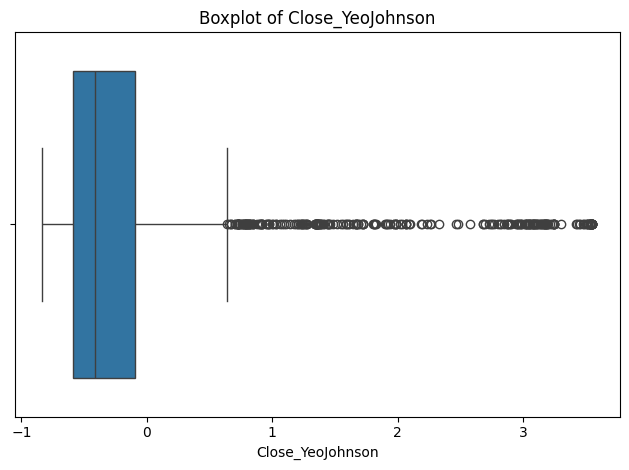

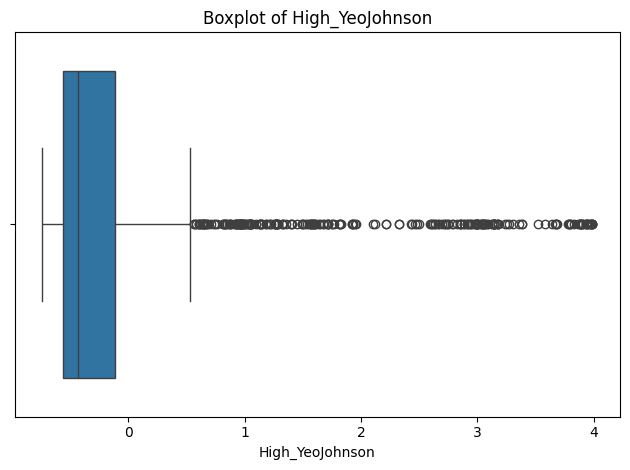

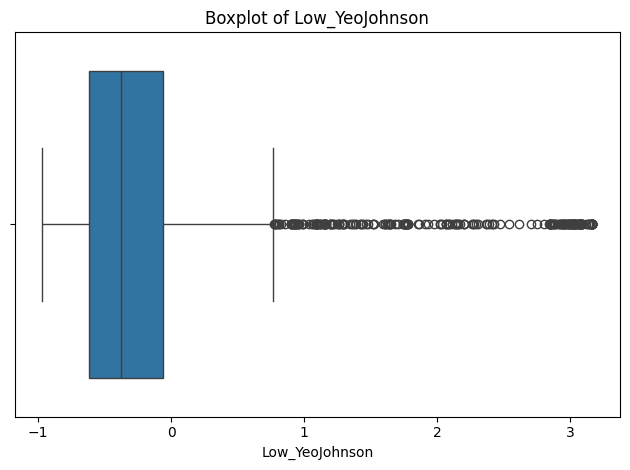

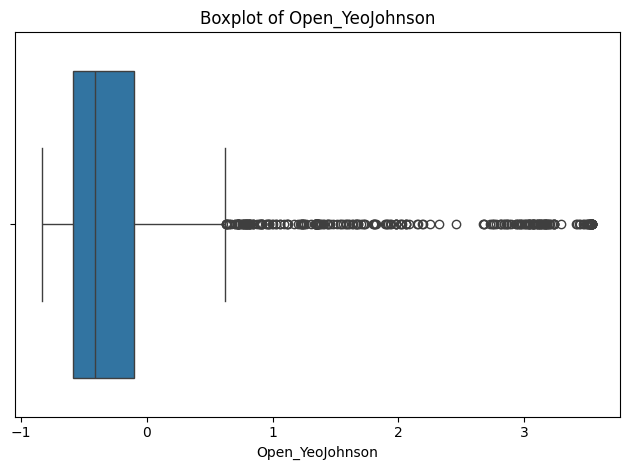

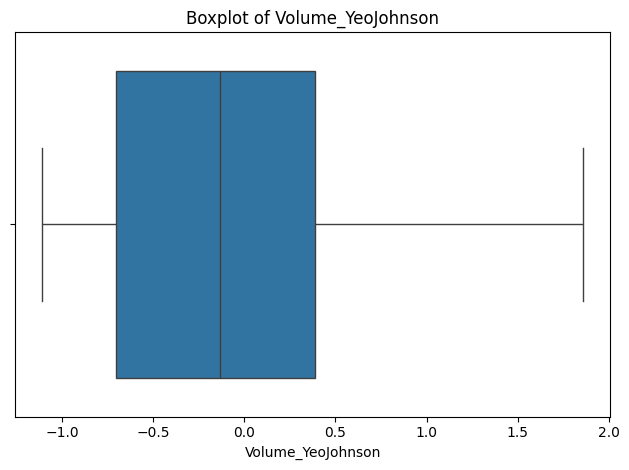

In [37]:
# Loop through all columns ending with '_YeoJohnson'
for col in [c for c in df_updated.columns if c.endswith('_YeoJohnson')]:
    plt.figure()
    sns.boxplot(x=df_updated[col], orient='h')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [39]:
df_updated.shape

(1759, 49)

#### Capping - Winsorization Method

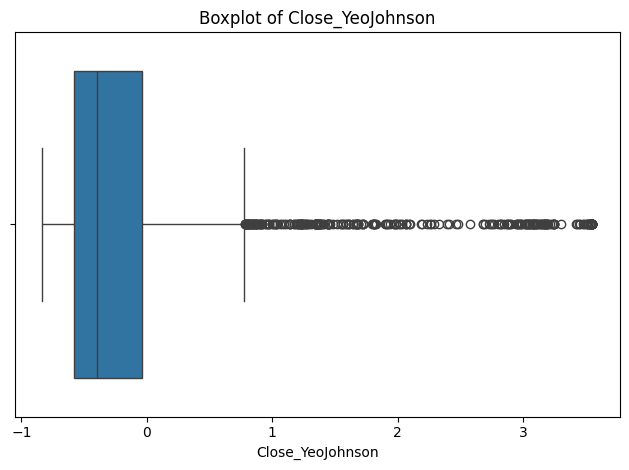

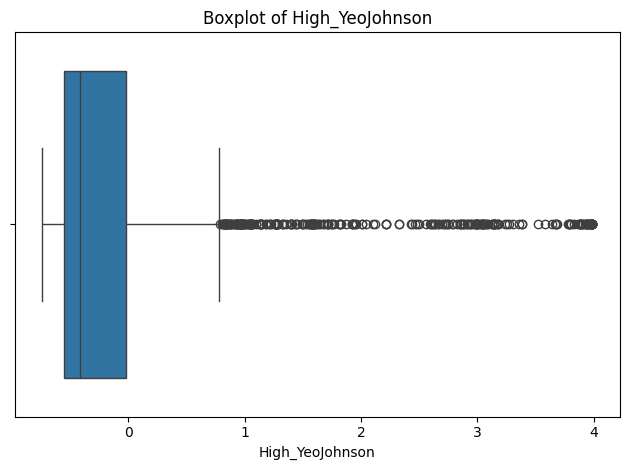

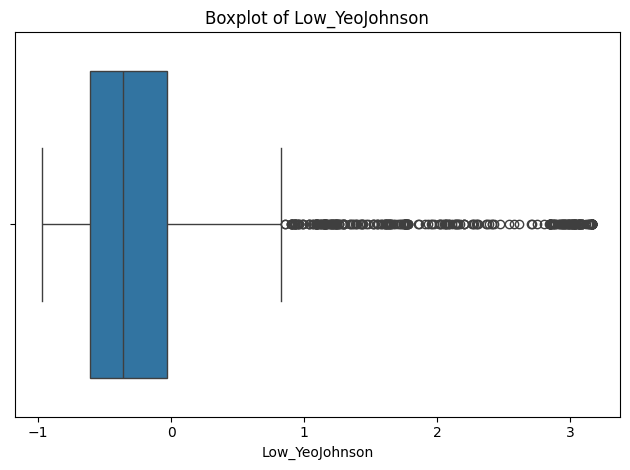

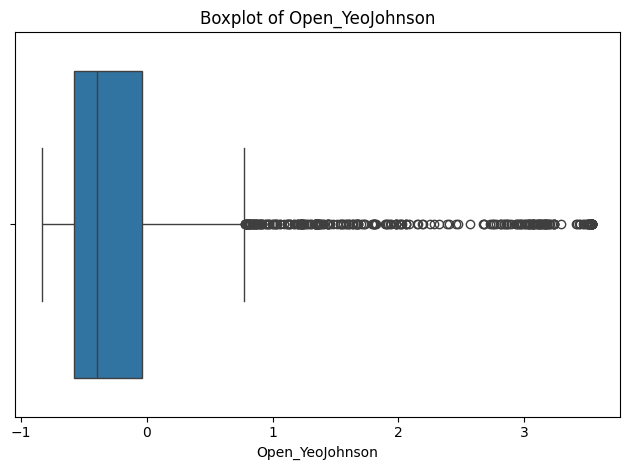

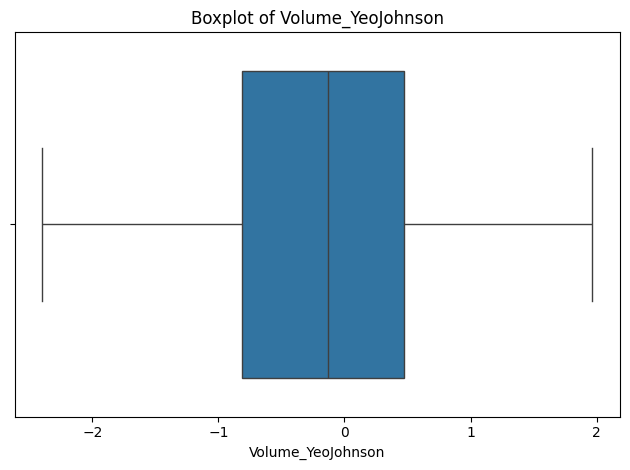

In [40]:
# Loop through all columns ending with '_YeoJohnson'
for col in [c for c in df_new.columns if c.endswith('_YeoJohnson')]:
    plt.figure()
    sns.boxplot(x=df_new[col], orient='h')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [41]:
lower_limit = df_new['Volume_YeoJohnson'].quantile(0.01)
upper_limit = df_new['Volume_YeoJohnson'].quantile(0.99)

In [42]:
df_winsorized = df_new.copy()

In [43]:
df_winsorized['Volume_YeoJohnson'] = np.where(df_new['Volume_YeoJohnson'] <= lower_limit, 
      lower_limit, 
      np.where(df_new['Volume_YeoJohnson'] >= upper_limit,
      upper_limit,
      df_new['Volume_YeoJohnson']))

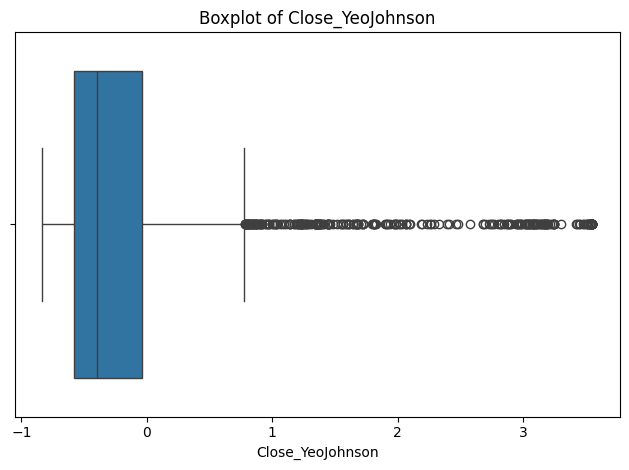

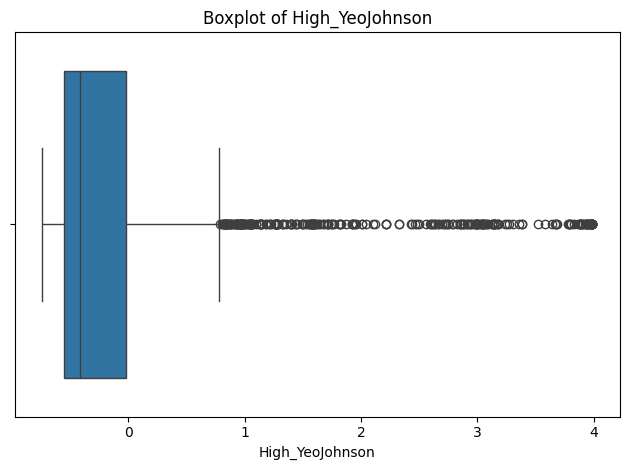

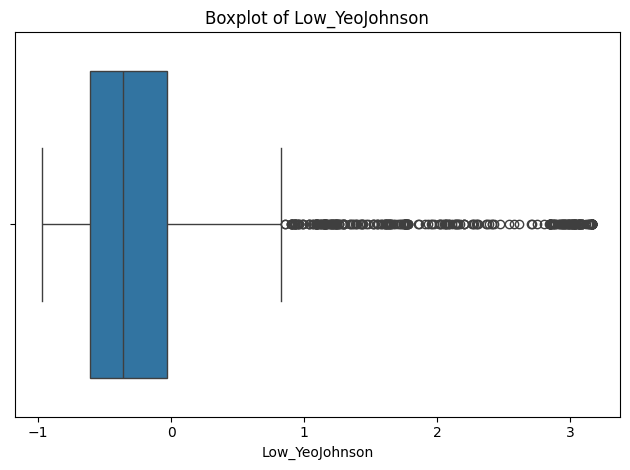

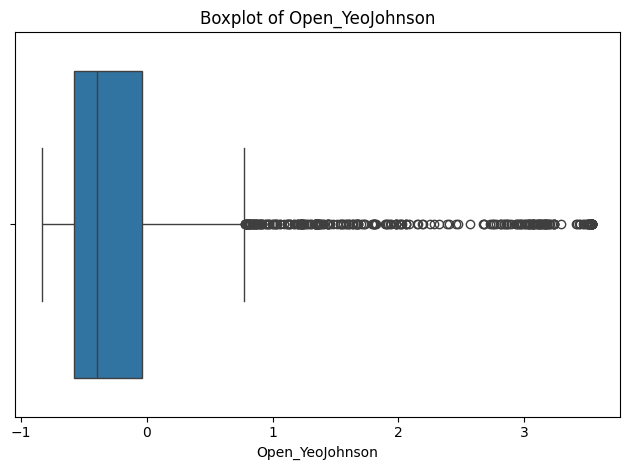

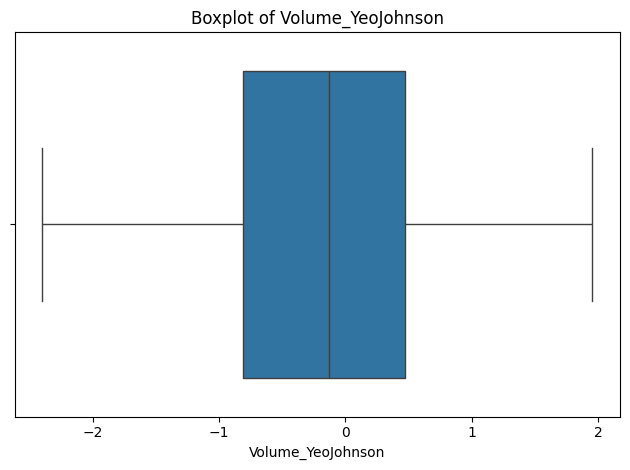

In [44]:
# Loop through all columns ending with '_YeoJohnson'
for col in [c for c in df_winsorized.columns if c.endswith('_YeoJohnson')]:
    plt.figure()
    sns.boxplot(x=df_winsorized[col], orient='h')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## Multivariate Analysis

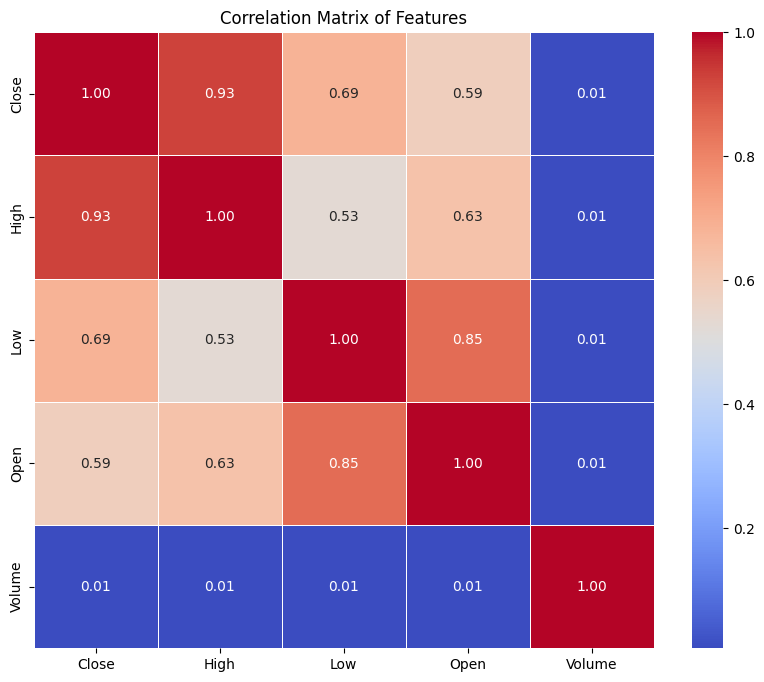

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True,
            cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

# --- Correlation Matrix Explaination ---

# OHLC features (Open, High, Low, Close) show almost perfect correlation (~1.00) with each other

# If the market is up, all four go up.
# If the market is down, all four go down.
# When trading volume increases, price tends to be higher.

In [46]:
df_winsorized.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Close_Log', 'Close_Sqrt',
       'Close_Cbrt', 'Close_Reciprocal', 'Close_YeoJohnson', 'Close_BoxCox',
       'Close_Standard', 'Close_MinMax', 'Close_Robust', 'High_Log',
       'High_Sqrt', 'High_Cbrt', 'High_Reciprocal', 'High_YeoJohnson',
       'High_BoxCox', 'High_Standard', 'High_MinMax', 'High_Robust', 'Low_Log',
       'Low_Sqrt', 'Low_Cbrt', 'Low_Reciprocal', 'Low_YeoJohnson',
       'Low_BoxCox', 'Low_Standard', 'Low_MinMax', 'Low_Robust', 'Open_Log',
       'Open_Sqrt', 'Open_Cbrt', 'Open_Reciprocal', 'Open_YeoJohnson',
       'Open_BoxCox', 'Open_Standard', 'Open_MinMax', 'Open_Robust',
       'Volume_Log', 'Volume_Sqrt', 'Volume_Cbrt', 'Volume_Reciprocal',
       'Volume_YeoJohnson', 'Volume_Standard', 'Volume_MinMax',
       'Volume_Robust'],
      dtype='object')

In [48]:
df_winsorized = df_winsorized[[
    'Open_YeoJohnson', 'High_YeoJohnson', 'Low_YeoJohnson',
    'Close_YeoJohnson', 'Volume_YeoJohnson'
]]

df_winsorized.head()

,Open_YeoJohnson,High_YeoJohnson,Low_YeoJohnson,Close_YeoJohnson,Volume_YeoJohnson
Date,,,,,
2019-10-21,3.514544,3.806009,3.165939,3.519692,1.860212
2019-10-22,3.507835,3.980271,3.167698,3.554527,1.954627
2019-10-23,3.542557,3.984686,3.169644,3.554677,1.906602
2019-10-24,3.542706,3.985877,3.169956,3.554703,1.903559
2019-10-25,3.542732,3.985805,3.169928,3.553756,1.869842


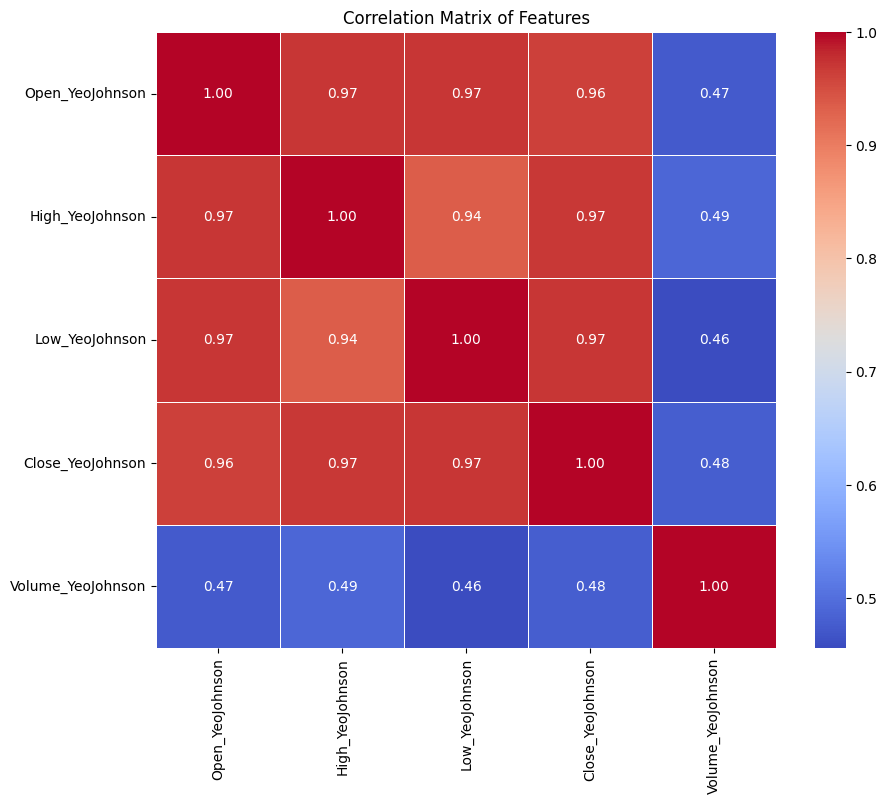

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_winsorized.corr(numeric_only=True), annot=True,
            cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

## Time Series Specific Checks

#### Trend Visualization

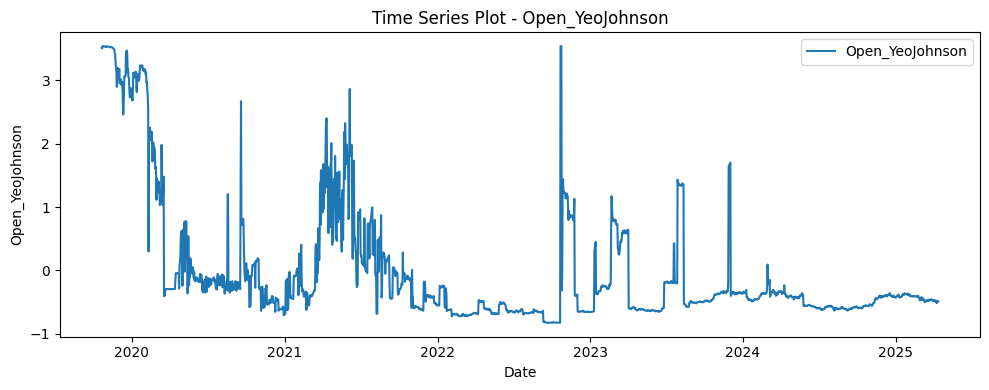

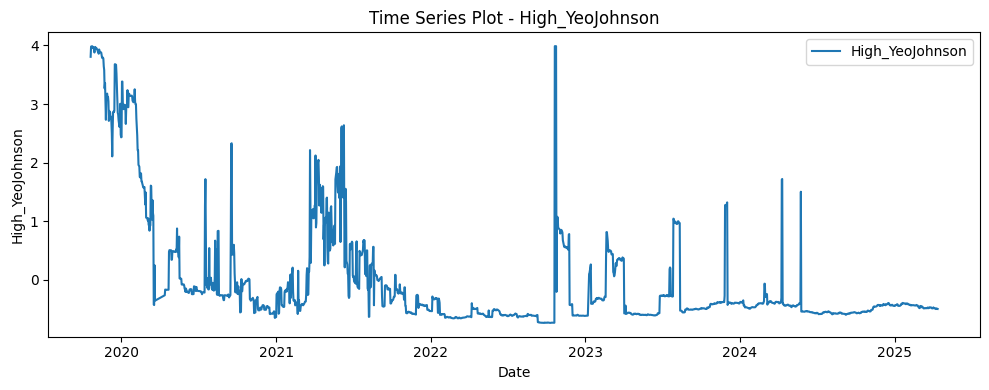

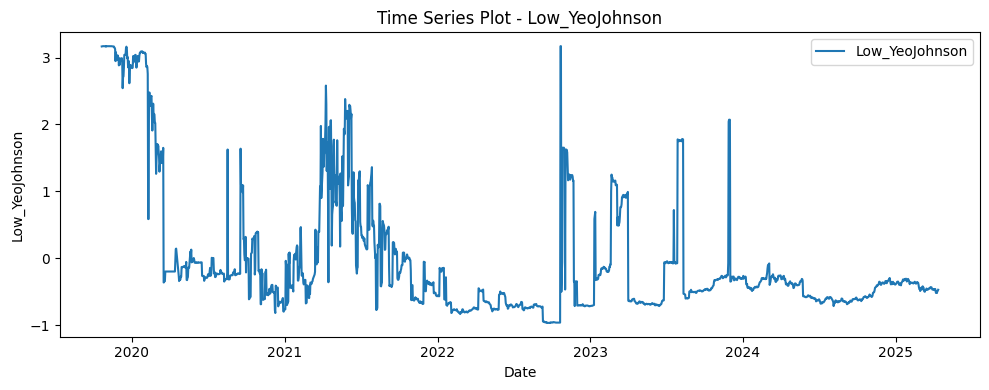

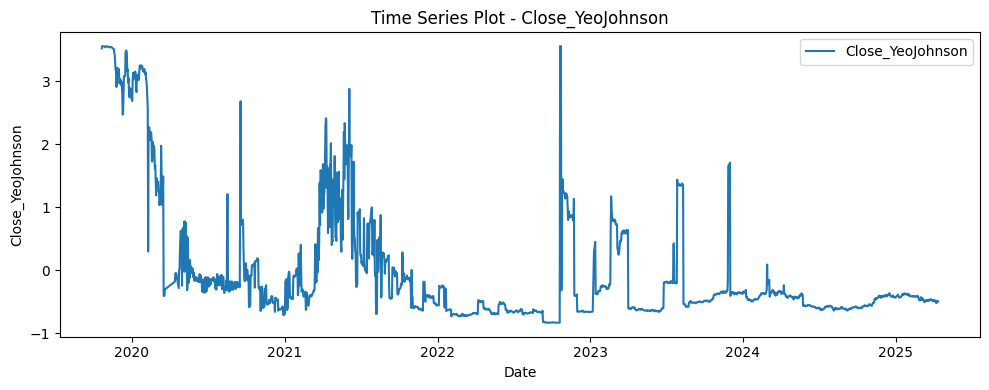

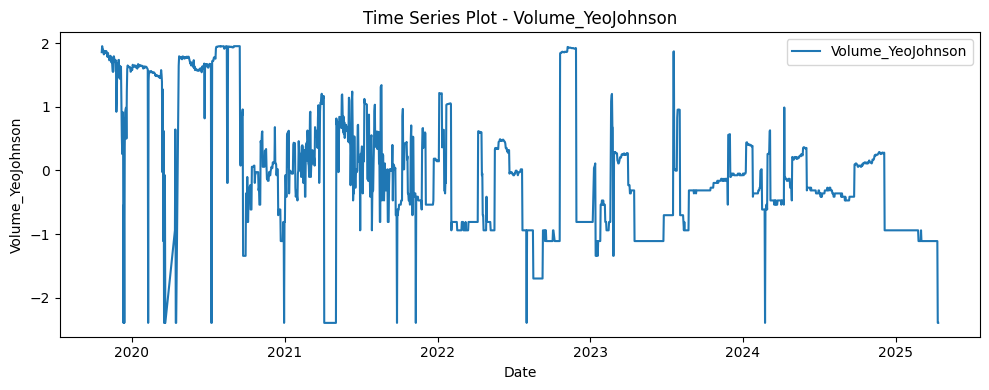

In [50]:
import matplotlib.pyplot as plt

# Plot each time series column
for col in df_winsorized.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(10, 4))
    plt.plot(df_winsorized.index, df_winsorized[col], label=col)
    plt.title(f'Time Series Plot - {col}')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

#### Stationarity Check

In [51]:
# KPSS Test for Stationarity
from statsmodels.tsa.stattools import kpss

for col in df_winsorized.select_dtypes(include=['float64', 'int64']).columns:
    print(f"\n================= KPSS Test for {col} =================")
    try:
        statistic, p_value, n_lags, critical_values = kpss(
            df_winsorized[col].dropna(), regression='c', nlags="auto")
        print(f"KPSS Statistic: {statistic}")
        print(f"p-value: {p_value}")
        print(f"Used lags: {n_lags}")
        # for key, value in critical_values.items():
        #     print(f"Critical Value ({key}): {value}")

        if p_value < 0.05:
            print("❌ The series is likely non-stationary (reject H₀).")
        else:
            print("✅ The series is likely stationary (fail to reject H₀).")
    except Exception as e:
        print(f"⚠️ Could not perform KPSS test on {col}: {e}")


================= KPSS Test for Open_YeoJohnson =================
KPSS Statistic: 2.224360414449117
p-value: 0.01
Used lags: 27
❌ The series is likely non-stationary (reject H₀).

================= KPSS Test for High_YeoJohnson =================
KPSS Statistic: 2.3290530274963768
p-value: 0.01
Used lags: 27
❌ The series is likely non-stationary (reject H₀).

================= KPSS Test for Low_YeoJohnson =================
KPSS Statistic: 2.0464620952074637
p-value: 0.01
Used lags: 27
❌ The series is likely non-stationary (reject H₀).

================= KPSS Test for Close_YeoJohnson =================
KPSS Statistic: 2.2185499238214073
p-value: 0.01
Used lags: 27
❌ The series is likely non-stationary (reject H₀).

================= KPSS Test for Volume_YeoJohnson =================
KPSS Statistic: 2.5437885100241124
p-value: 0.01
Used lags: 26
❌ The series is likely non-stationary (reject H₀).


C:\Users\parth\AppData\Local\Temp\ipykernel_34844\1003007198.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(
C:\Users\parth\AppData\Local\Temp\ipykernel_34844\1003007198.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(
C:\Users\parth\AppData\Local\Temp\ipykernel_34844\1003007198.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(
C:\Users\parth\AppData\Local\Temp\ipykernel_34844\1003007198.py:7: InterpolationWarning: The test statistic is outside of the range of p

In [52]:
# ADF Test for Stationarity
from statsmodels.tsa.stattools import adfuller

for col in df_winsorized.select_dtypes(include=['float64', 'int64']).columns:
    print(f"\n================= ADF Test for {col} =================")
    result = adfuller(df_winsorized[col].dropna())
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    # for key, value in result[4].items():
    #     print(f"Critical Value ({key}): {value}")

    if result[1] <= 0.05:
        print("✅ The series is likely stationary (reject H₀).")
    else:
        print("❌ The series is likely non-stationary (fail to reject H₀).")


================= ADF Test for Open_YeoJohnson =================
ADF Statistic: -4.036045470842502
p-value: 0.0012330933146662104
✅ The series is likely stationary (reject H₀).

================= ADF Test for High_YeoJohnson =================
ADF Statistic: -4.402338970906674
p-value: 0.0002940161732071752
✅ The series is likely stationary (reject H₀).

================= ADF Test for Low_YeoJohnson =================
ADF Statistic: -3.8491129796227574
p-value: 0.0024429573931076384
✅ The series is likely stationary (reject H₀).

================= ADF Test for Close_YeoJohnson =================
ADF Statistic: -4.090229714307928
p-value: 0.0010051733591499921
✅ The series is likely stationary (reject H₀).

================= ADF Test for Volume_YeoJohnson =================
ADF Statistic: -5.742644842460049
p-value: 6.22413429110133e-07
✅ The series is likely stationary (reject H₀).
